# RB-F05 v1：digitalの微分教師とDML

**問い：** 正しいGreek教師を作る費用を含めても、DMLに利点があるか。

配当なしGBM、cash-or-nothing call、現金額1、K=100、r=3%、sigma=20%。
S=80–120、T=0.05–2年。合成データ、CPUの小型ネットによる研究。
train512・validation128・test200を分離し、初期化seed11/29/47をすべて保存した。
price-onlyとLRM-DMLは同じネット、教師・共通初期化込み各8秒。
validation/testで損失重み・設定・checkpointを選ばない。

このnotebookは保存済みJSON/NPZを表示するだけで、torch・MC・学習を実行しない。
教師・保存重みからの独立推論・指標再計算はbuild_reference.py --checkとテストで確認する。
設計・実行方法・採否・出典はREADME.mdを参照。


In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

data = json.loads(Path("reference.json").read_text())
with np.load("reference.npz", allow_pickle=False) as source:
    arrays = {key: source[key] for key in source.files}
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
display(Markdown("**固定pilot：6SE＋参照誤差2e-12。** 本実験を見て判定幅を変えない。"))


**固定pilot：6SE＋参照誤差2e-12。** 本実験を見て判定幅を変えない。

## 1. pathwise=0と、正しいLRM教師はどう違うか

正しいGBMは $S_T=S\exp((r-\sigma^2/2)T+\sigma\sqrt{T}Z)$。
digital価格は $e^{-rT}N(d_2)$、deltaは $e^{-rT}\phi(d_2)/(S\sigma\sqrt T)$。
LRM教師は $e^{-rT}1_{S_T>K}Z/(S\sigma\sqrt T)$。
素朴なpathwiseは0であり、試行を増やしてもbiasが残る。

条件付き期待値はGBM増分を厳密に積分消去し、同じdigitalを価格付けする。
rampは異なるpayoffへの置換で、digitalに対するbiasを持つ。
CRN中央差分は有限幅0.1の差分の不偏推定で、真のdeltaとの差には打切りbiasがある。
下図はATMの3満期に対する観測誤差。誤差棒は±6SEで、ramp/pathwiseを受入判定に使わない。


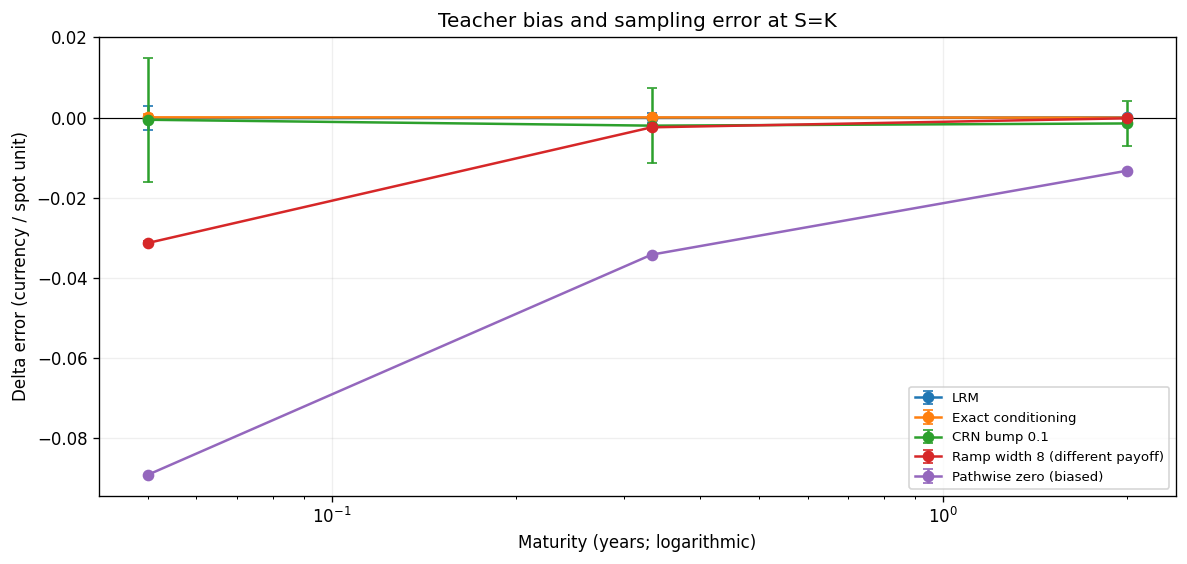

In [2]:
indices = np.array([1, 4, 7])
times = arrays["diagnostic_inputs"][indices, 1]
target = arrays["diagnostic_target"][indices, 1]
fig, ax = plt.subplots(figsize=(10, 4.8))
labels = {"lrm": "LRM", "conditional": "Exact conditioning", "crn": "CRN bump 0.1",
          "ramp": "Ramp width 8 (different payoff)", "pathwise": "Pathwise zero (biased)"}
for method, label in labels.items():
    mean = arrays["diagnostic_" + method + "_mean"][indices, 1]
    se = arrays["diagnostic_" + method + "_se"][indices, 1]
    ax.errorbar(times, mean - target, yerr=6*se, marker="o", capsize=3, label=label)
ax.axhline(0, color="black", linewidth=.7)
ax.set_xscale("log")
ax.set_xlabel("Maturity (years; logarithmic)")
ax.set_ylabel("Delta error (currency / spot unit)")
ax.set_title("Teacher bias and sampling error at S=K")
ax.legend(fontsize=8)
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()


## 2. 距離と満期で誤差はどう変わるか

同じ教師・3つのpaired seedを使う。全seedを残し、良かったseedだけを選ばない。
下図はtestの平均絶対誤差。価格とGreekの補間は、解析価格・deltaから作ったHermite曲線と
log満期方向の線形補間で、教師費用が違う強い比較器である。
横軸はS/K、縦軸は離散的な満期の行。各行の3図は同じ色目盛。


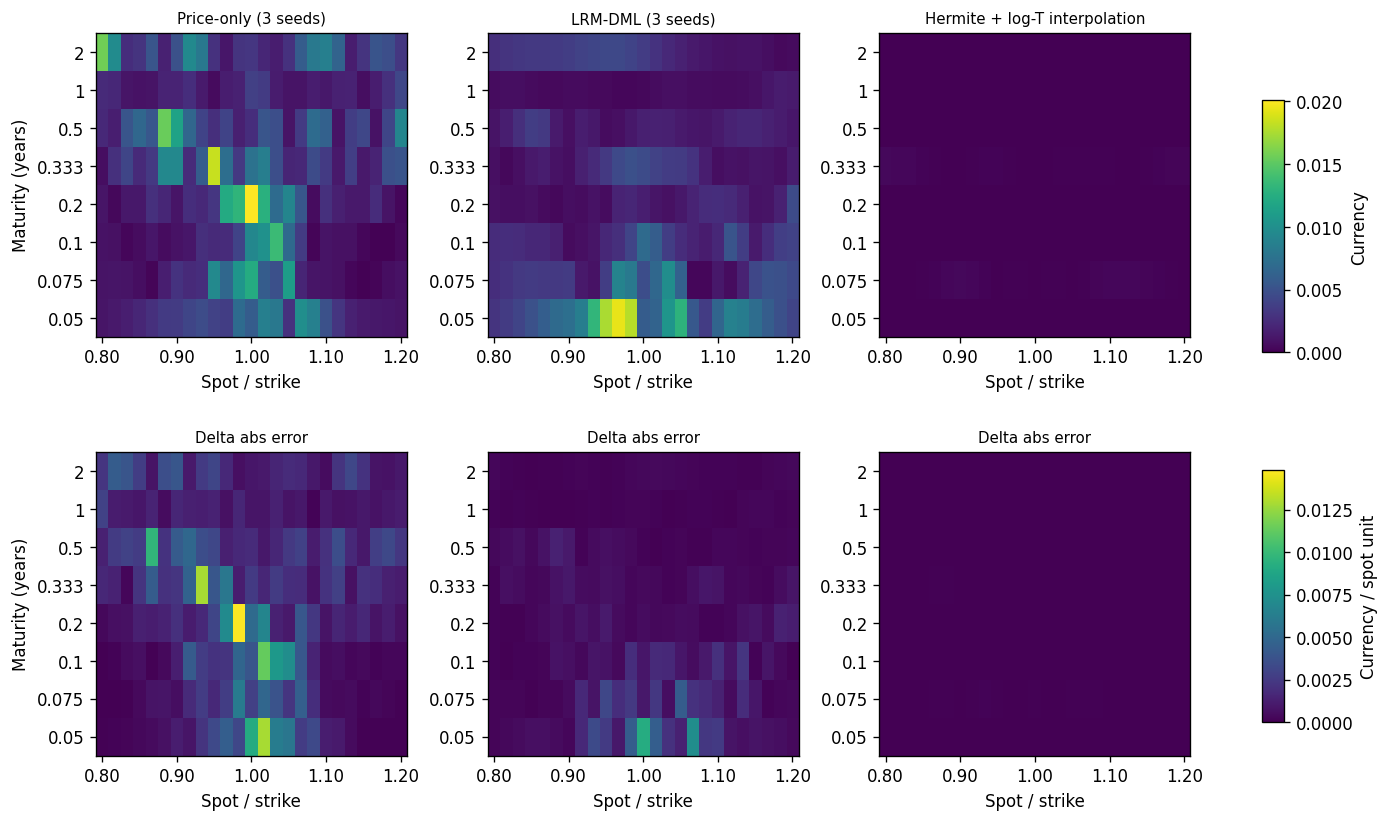

In [3]:
shape = (len(data["grid"]["times"]), len(data["grid"]["spots"]))
groups = [
    ("Price-only (3 seeds)", np.mean([np.abs(arrays[f"price_{s}_test_error"]) for s in data["seeds"]], axis=0)),
    ("LRM-DML (3 seeds)", np.mean([np.abs(arrays[f"dml_{s}_test_error"]) for s in data["seeds"]], axis=0)),
    ("Hermite + log-T interpolation", np.abs(arrays["hermite_prediction"] - arrays["test_target"])),
]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for row, name in enumerate(["Price abs error", "Delta abs error"]):
    vmax = max(float(np.max(values[:, row])) for _, values in groups)
    for col, (label, values) in enumerate(groups):
        image = axes[row, col].imshow(values[:, row].reshape(shape), origin="lower",
                                     aspect="auto", vmin=0, vmax=vmax, cmap="viridis")
        axes[row, col].set_title(label if row == 0 else name, fontsize=9)
        axes[row, col].set_xticks([0, 6, 12, 18, 24], ["0.80", "0.90", "1.00", "1.10", "1.20"])
        axes[row, col].set_yticks(np.arange(shape[0]), [f"{t:.3g}" for t in data["grid"]["times"]])
        axes[row, col].set_xlabel("Spot / strike")
        if col == 0:
            axes[row, col].set_ylabel("Maturity (years)")
    color_axis = fig.add_axes([.88, .56 if row == 0 else .12, .015, .30])
    fig.colorbar(image, cax=color_axis,
                 label="Currency" if row == 0 else "Currency / spot unit")
fig.subplots_adjust(left=.07, right=.83, bottom=.08, top=.94, hspace=.38, wspace=.26)
plt.show()


## 3. 学習費用まで含めると回収できるか

教師生成・共通初期化・学習・検証・OOD判定・解析fallbackを費用に含める。
入力が領域外ならネットを使わず解析値へ戻す。推論比較は同じ204件のbatch（うち4件OOD）を使う。
総費用はoffline＋1000件×観測online秒/件。各seedは別の単独導入として教師/初期化費用を計上する。
正確な解析式が既に安い商品で、DMLが速度に勝つとは仮定しない。
計時はこのCPU・thread設定での観測で、環境共通の速度gateではない。


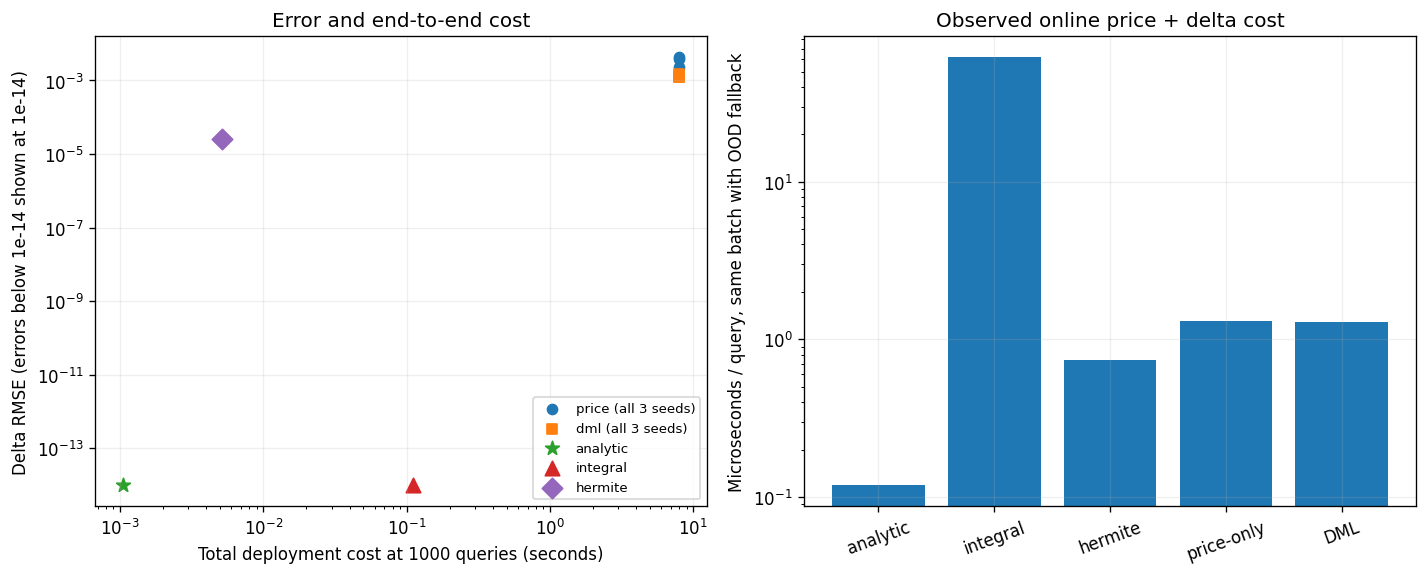

|seed|price-only価格RMSE|DML価格RMSE|price-only delta RMSE|DML delta RMSE|
|---|---:|---:|---:|---:|
|11|0.0060969|0.0040863|0.004254|0.0012424|
|29|0.0061232|0.0045216|0.0038646|0.0012768|
|47|0.0046465|0.0044157|0.0022824|0.0015398|

**全seedの品質条件：** True。**速度での標準採用条件：** False。回収不能は、誤差の良さだけで採用へ変えない。

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.9))
for method, marker in [("price_", "o"), ("dml_", "s")]:
    runs = [r for r in data["runs"] if r["name"].startswith(method)]
    axes[0].scatter([r["total_at_1000_s"] for r in runs],
                    [r["test"]["delta_rmse"] for r in runs],
                    marker=marker, label=method[:-1] + " (all 3 seeds)")
for baseline, marker in zip(data["baselines"], ["*", "^", "D"]):
    axes[0].scatter(baseline["total_at_1000_s"], max(baseline["test"]["delta_rmse"], 1e-14),
                    marker=marker, s=75, label=baseline["name"])
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("Total deployment cost at 1000 queries (seconds)")
axes[0].set_ylabel("Delta RMSE (errors below 1e-14 shown at 1e-14)")
axes[0].set_title("Error and end-to-end cost")
axes[0].legend(fontsize=8)
names = [b["name"] for b in data["baselines"]] + ["price-only", "DML"]
costs = [b["online_s_per_query"]*1e6 for b in data["baselines"]]
costs += [np.mean([r["online_s_per_query"] for r in data["runs"] if r["dml"] == flag])*1e6
          for flag in [False, True]]
axes[1].bar(names, costs)
axes[1].set_yscale("log")
axes[1].set_ylabel("Microseconds / query, same batch with OOD fallback")
axes[1].set_title("Observed online price + delta cost")
axes[1].tick_params(axis="x", rotation=20)
for ax in axes:
    ax.grid(alpha=.2)
fig.tight_layout()
plt.show()

rows = ["|seed|price-only価格RMSE|DML価格RMSE|price-only delta RMSE|DML delta RMSE|",
        "|---|---:|---:|---:|---:|"]
for seed in data["seeds"]:
    p = next(r for r in data["runs"] if r["name"] == f"price_{seed}")["test"]
    d = next(r for r in data["runs"] if r["name"] == f"dml_{seed}")["test"]
    rows.append(f"|{seed}|{p['price_rmse']:.5g}|{d['price_rmse']:.5g}|{p['delta_rmse']:.5g}|{d['delta_rmse']:.5g}|")
display(Markdown("\n".join(rows)))
display(Markdown("**全seedの品質条件：** " + str(data["adoption"]["dml_quality_all_seeds"])
                 + "。**速度での標準採用条件：** " + str(data["adoption"]["standard_speed_adoption"])
                 + "。回収不能は、誤差の良さだけで採用へ変えない。"))


## 採用と後続

教師の検証と教育用の比較は採用し、速度を理由とした標準器への昇格は独立に判断する。
ネットワークの精度・速度はこの合成領域とCPU予算での結果であり、論文の数値実験の再現ではない。
離散バリアは監視日・接触・rebate・独立参照を確定してから別実験にする。0DTE/roughはさらに後続。
本編Book/portal、正式な節台帳、既存vol18の学習配列をこの研究で置換しない。
